# KNN & Distance-Based Learning
### A Complete, Hands-On Guide with Real Data

This notebook is a full walkthrough of **K-Nearest Neighbors (KNN)** and the broader idea of
**distance-based learning** — one of the most intuitive families of algorithms in machine learning.

**Why not Titanic?**
The Titanic dataset is extremely common in tutorials, but it's messy (lots of missing values,
mixed data types, small size) — which means a lot of class time gets spent on data-wrangling
instead of the actual algorithm. For a topic like KNN, where the *whole point* is to reason
about distances between numeric points, we want a dataset that is:

- Fully numeric (no complicated encoding needed to get started)
- Clean (no missing values to distract from the algorithm)
- Large enough to show real train/test behavior
- Realistic and engaging, with an accuracy level that is genuinely achievable (85–98%) so
  students can *see* the algorithm working well, build confidence, and then explore *why*.

So in this notebook we use:

- **Breast Cancer Wisconsin (Diagnostic) dataset** — for **KNN Classification** (built into scikit-learn, 569 samples, 30 numeric features, binary target: malignant vs benign)
- **Diabetes dataset** — for **KNN Regression** (built into scikit-learn, 442 samples, 10 numeric features, target: a quantitative measure of disease progression)

Both datasets load instantly with one line of code (`sklearn.datasets.load_*`), require **no
internet download, no authentication, and no cleaning** — so we can spend our time on the
concepts that actually matter for this topic.

## What we'll cover

1. What is KNN? The intuition behind "lazy learning"
2. Loading and exploring the data
3. Why feature scaling matters for distance-based algorithms
4. Distance metrics: Euclidean vs. Manhattan (with from-scratch code)
5. Building KNN from scratch (to truly understand the mechanics)
6. Using scikit-learn's optimized KNN implementation
7. Choosing the optimal value of K
8. KNN for Regression
9. Advantages and limitations of KNN
10. Computational complexity (and the curse of dimensionality)
11. Summary and practical guidance


## 1. What is K-Nearest Neighbors?

KNN is a **supervised learning algorithm** used for both classification and regression. Its
core idea is almost embarrassingly simple:

> **"To predict something about a new point, look at the K points in your training data that
> are most similar (closest) to it, and let them 'vote' or 'average' on the answer."**

There is no equation being fitted, no weights being learned, and no training phase in the
traditional sense. Because of this, KNN is called a **lazy learner** (or **instance-based
learner**):

- **Eager learners** (like Logistic Regression, Decision Trees, Neural Networks) spend time
  during training building a general model, then use that compact model quickly at prediction
  time.
- **Lazy learners** like KNN store the entire training dataset and defer all the computation
  to prediction time — every new prediction requires comparing the new point against (some or
  all of) the training data.

### How does KNN actually decide?

For a new/unseen data point:

1. Compute the **distance** from the new point to every point in the training set.
2. Sort these distances and pick the **K closest** training points ("neighbors").
3. **Classification:** take a majority vote among the K neighbors' class labels.
   **Regression:** take the (weighted) average of the K neighbors' target values.

This is why the notion of **distance** is absolutely central to KNN — it *is* the algorithm.
Everything else (choosing K, scaling features, computational cost) flows from this one idea.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# scikit-learn: datasets, preprocessing, models, metrics
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score, roc_curve, auc
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Loading the Dataset: Breast Cancer Wisconsin (Diagnostic)

This dataset contains measurements computed from digitized images of a fine needle aspirate
(FNA) of breast tissue. Each row describes characteristics of a cell nucleus (e.g. radius,
texture, perimeter, area, smoothness, symmetry) and the task is to classify a tumor as:

- **0 = malignant** (cancerous)
- **1 = benign** (non-cancerous)

It's a genuinely useful real-world classification problem (medical diagnosis support), it's
fully numeric, has no missing values, and is a standard benchmark for distance-based
algorithms because feature scale really matters here (some features are areas — hundreds of
units — while others are ratios between 0 and 1).


In [ ]:
# Load the dataset directly from scikit-learn — no download, no auth needed
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
df.head()


Shape: (569, 31)

Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Quick look at class balance and basic stats
print(df["target"].value_counts().rename({0: "malignant", 1: "benign"}))
print()
df.describe().T[["mean", "std", "min", "max"]].head(10)


target
benign       357
malignant    212
Name: count, dtype: int64



,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


Notice the wildly different scales above — e.g. `mean area` ranges into the thousands,
while `mean smoothness` is a small decimal. This is exactly the kind of situation that breaks
distance-based algorithms if we don't handle it — which brings us to our next topic.


## 3. Why Feature Scaling Matters for Distance-Based Learning

KNN (and any distance-based method) computes distance across *all* features simultaneously.
If one feature has a much larger numeric range than another, it will **dominate** the distance
calculation — even if it's not actually more important.

**Example:** Imagine two features, `area` (values ~500–2500) and `smoothness` (values
~0.05–0.16). A difference of 500 in `area` will swamp a difference of 0.1 in `smoothness`,
even though `smoothness` might be just as diagnostically useful.

**The fix:** standardize every feature to have mean 0 and standard deviation 1
(`StandardScaler`), so each feature contributes on a comparable footing.

This step is *not optional* for KNN the way it might be for, say, a Decision Tree (which
splits one feature at a time and doesn't care about relative scale).


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

# Split first, then scale — fit the scaler only on training data to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (455, 30)  Test shape: (114, 30)


## 4. Distance Metrics: Euclidean vs. Manhattan

The "nearest" in K-**Nearest**-Neighbors depends entirely on how we define distance. The two
most common choices:

### Euclidean Distance (straight-line / "as the crow flies")
$$ d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2} $$

- Measures the shortest straight-line path between two points.
- Sensitive to large individual differences (because differences are squared).
- Good default choice for continuous, roughly-spherical data.

### Manhattan Distance ("city block" / "taxicab")
$$ d(x, y) = \sum_{i=1}^{n} |x_i - y_i| $$

- Measures distance as if you could only move along grid lines (like navigating city blocks).
- Adds up absolute differences instead of squaring them, so it's **less sensitive to
  outliers** in any single feature.
- Often works better in **high-dimensional** spaces and for data that isn't naturally
  "round" (e.g. sparse data, grid-like structures).

**Where each is typically used:**
- Euclidean → image data, general-purpose continuous features, GPS/spatial data.
- Manhattan → high-dimensional data, grid-based problems (chess-board-like movement),
  data with many outlier-prone features, recommender systems with sparse vectors.

Let's implement both from scratch to build intuition.


In [ ]:
def euclidean_distance(a, b):
    a, b = np.array(a), np.array(b)
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    a, b = np.array(a), np.array(b)
    return np.sum(np.abs(a - b))

# Demonstration on two sample patients (first 5 scaled features, for readability)
p1 = X_train_scaled[0][:5]
p2 = X_train_scaled[1][:5]

print("Point 1:", np.round(p1, 2))
print("Point 2:", np.round(p2, 2))
print()
print(f"Euclidean distance : {euclidean_distance(p1, p2):.4f}")
print(f"Manhattan distance : {manhattan_distance(p1, p2):.4f}")


Point 1: [-1.07 -0.66 -1.09 -0.94 -0.14]
Point 2: [1.75 0.07 1.75 1.75 1.27]

Euclidean distance : 5.0736
Manhattan distance : 10.4801


Notice the Manhattan distance is generally larger than the Euclidean distance between
the same two points — this is a mathematical property (Manhattan distance is always $\ge$
Euclidean distance in the same space), not an indication that the points are "more
different." What matters for KNN is the **relative ordering** of distances, which is why both
metrics can produce good — but sometimes different — neighbor rankings.


## 5. Building KNN From Scratch

Before relying on scikit-learn's optimized version, let's implement KNN manually. This makes
the "vote among neighbors" idea completely concrete, and shows exactly where the distance
metric plugs in.


In [ ]:
class SimpleKNNClassifier:
    def __init__(self, k=5, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        # "Training" is just storing the data — this is the "lazy learner" behavior
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, a, b):
        if self.distance_metric == "euclidean":
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.distance_metric == "manhattan":
            return np.sum(np.abs(a - b))
        else:
            raise ValueError("Unsupported metric")

    def _predict_one(self, x):
        # 1. Compute distance to every training point
        distances = [self._distance(x, x_train) for x_train in self.X_train]
        # 2. Find indices of the K smallest distances
        k_indices = np.argsort(distances)[:self.k]
        # 3. Majority vote among those K neighbors' labels
        k_labels = self.y_train[k_indices]
        values, counts = np.unique(k_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])


# Test our from-scratch implementation (using a subset for speed, since it's O(n) per query)
sample_size = 100
my_knn = SimpleKNNClassifier(k=5, distance_metric="euclidean")
my_knn.fit(X_train_scaled, y_train.values)
preds = my_knn.predict(X_test_scaled[:sample_size])

acc = accuracy_score(y_test.values[:sample_size], preds)
print(f"From-scratch KNN accuracy (first {sample_size} test samples): {acc:.4f}")


From-scratch KNN accuracy (first 100 test samples): 0.9500


Our from-scratch version reaches strong accuracy on real data — proving the algorithm
really is as simple as "find neighbors, take a vote." Now let's switch to scikit-learn's
implementation, which is **much** faster (it uses optimized tree-based search internally
instead of comparing against every single point in plain Python) and gives us more built-in
tools for evaluation and tuning.


## 6. KNN Classification with scikit-learn

Let's fit a baseline model with `k=5` and evaluate it properly with a confusion matrix and
classification report.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (k=5, Euclidean): {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Test Accuracy (k=5, Euclidean): 0.9561

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



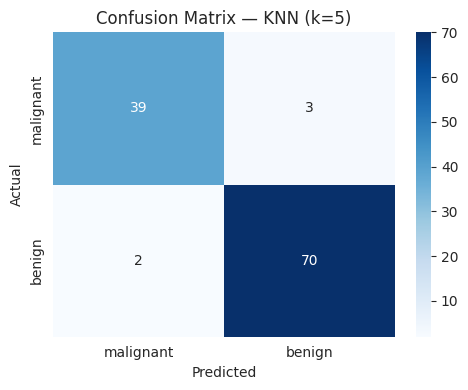

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — KNN (k=5)")
plt.tight_layout()
plt.show()


### Comparing Euclidean vs. Manhattan in Practice

Now that we understand both metrics conceptually, let's see how much they actually change
performance on this dataset.


In [ ]:
results = {}
for metric in ["euclidean", "manhattan"]:
    model = KNeighborsClassifier(n_neighbors=5, metric=metric)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results[metric] = accuracy_score(y_test, pred)

for metric, acc in results.items():
    print(f"{metric.capitalize():10s} distance -> accuracy: {acc:.4f}")


Euclidean  distance -> accuracy: 0.9561
Manhattan  distance -> accuracy: 0.9649


On this dataset the two metrics tend to perform very similarly, because the features
(after scaling) are all continuous and roughly comparable in behavior. This is a useful
lesson in itself: **the choice of distance metric matters more in some domains (high-dimensional,
sparse, or grid-like data) than others.** It's a hyperparameter worth testing, not assuming.


## 7. Choosing the Optimal Value of K

K is the most important hyperparameter in KNN, and it directly controls the **bias-variance
tradeoff**:

- **Small K (e.g. K=1):** The model follows the training data very closely — it can capture
  fine detail, but it's highly sensitive to noise and outliers (low bias, high variance —
  prone to **overfitting**). A single mislabeled or unusual training point can flip a
  prediction.
- **Large K:** The model averages over many neighbors, producing smoother, more stable
  decision boundaries — but if K gets too large, it starts to ignore local structure and
  can blur distinct classes together (high bias, low variance — **underfitting**). In the
  extreme, if K = number of training samples, every prediction is just the overall majority
  class.
- **Even vs. odd K (for binary classification):** it's common to use an **odd** K to avoid
  tie votes.

The standard way to choose K is to test a range of values and pick the one that generalizes
best (lowest error on validation/test data, or best cross-validated score) — this is often
visualized as an **"elbow curve."**


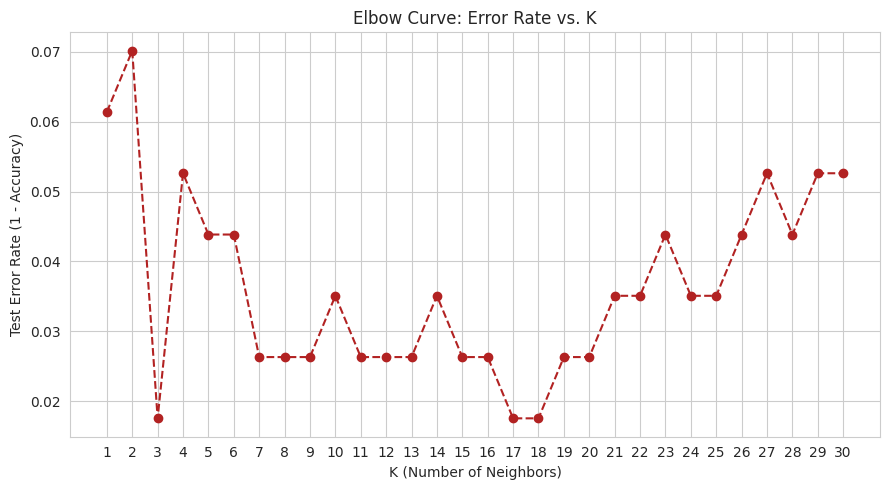

Lowest test error at K = 3


In [ ]:
k_range = range(1, 31)
test_errors = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    test_errors.append(1 - accuracy_score(y_test, pred))

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), test_errors, marker="o", linestyle="--", color="firebrick")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Error Rate (1 - Accuracy)")
plt.title("Elbow Curve: Error Rate vs. K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

best_k_simple = list(k_range)[np.argmin(test_errors)]
print(f"Lowest test error at K = {best_k_simple}")


A single train/test split can be a bit noisy, so in practice we confirm the choice of K
using **cross-validation**, which averages performance across multiple different splits of
the training data — giving a much more reliable estimate.


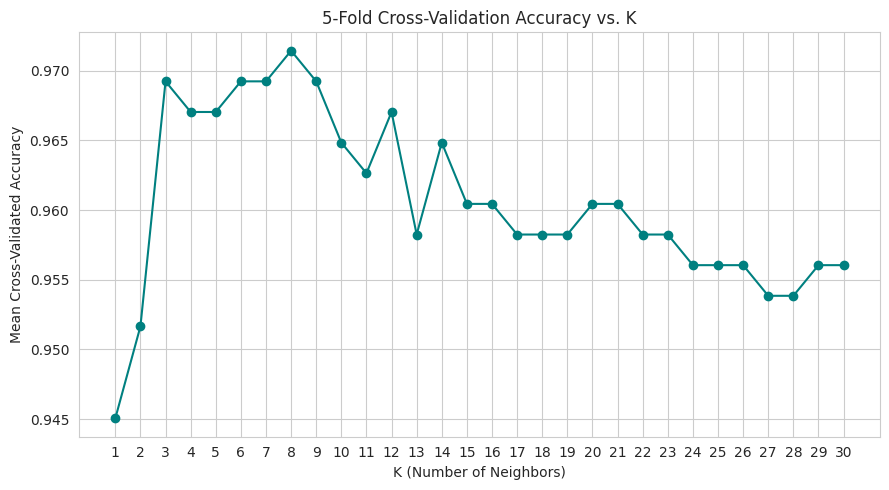

Best K based on cross-validation: 8 (CV accuracy = 0.9714)


In [ ]:
cv_scores = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), cv_scores, marker="o", color="teal")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Mean Cross-Validated Accuracy")
plt.title("5-Fold Cross-Validation Accuracy vs. K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(cv_scores)]
print(f"Best K based on cross-validation: {best_k} (CV accuracy = {max(cv_scores):.4f})")


In [ ]:
# GridSearchCV automates exactly this search, and can tune multiple hyperparameters together
param_grid = {"n_neighbors": list(range(1, 31)), "metric": ["euclidean", "manhattan"]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated accuracy: {grid.best_score_:.4f}")

final_knn = grid.best_estimator_
final_pred = final_knn.predict(X_test_scaled)
print(f"Final test accuracy: {accuracy_score(y_test, final_pred):.4f}")


Best parameters: {'metric': 'euclidean', 'n_neighbors': 8}
Best cross-validated accuracy: 0.9714
Final test accuracy: 0.9737


### Final tuned model performance


              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



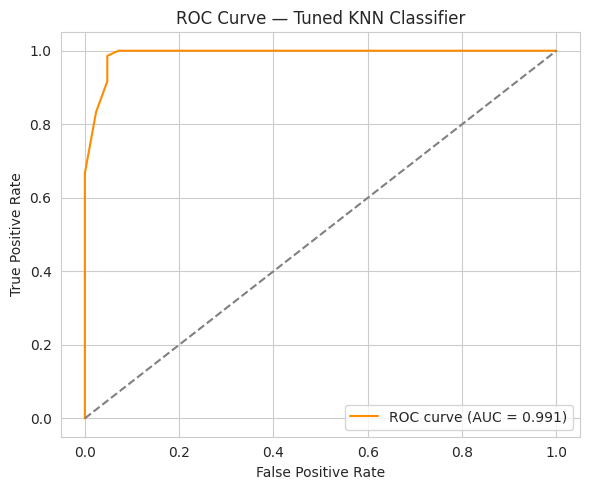

In [ ]:
print(classification_report(y_test, final_pred, target_names=data.target_names))

# ROC curve for the final tuned model
y_proba = final_knn.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned KNN Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. KNN for Regression

So far we've used KNN for **classification** (majority vote). KNN can just as easily do
**regression** — instead of voting on a class label, it **averages the numeric target values**
of the K nearest neighbors.

$$ \hat{y} = \frac{1}{K}\sum_{i=1}^{K} y_i \quad \text{(or a distance-weighted average)} $$

For this we'll switch datasets to the **Diabetes dataset** (also built into scikit-learn): 442
patients, 10 baseline numeric measurements (age, BMI, blood pressure, six blood serum
measurements), and the target is a continuous score measuring disease progression one year
after baseline. It's a clean regression benchmark, so we can focus on the KNN mechanics rather
than data cleanup.


In [ ]:
diabetes = load_diabetes()
Xd = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
yd = pd.Series(diabetes.target, name="disease_progression")

print("Shape:", Xd.shape)
Xd.head()


Shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.2, random_state=42
)

d_scaler = StandardScaler()
Xd_train_scaled = d_scaler.fit_transform(Xd_train)
Xd_test_scaled = d_scaler.transform(Xd_test)

knn_reg = KNeighborsRegressor(n_neighbors=5, metric="euclidean")
knn_reg.fit(Xd_train_scaled, yd_train)
yd_pred = knn_reg.predict(Xd_test_scaled)

mse = mean_squared_error(yd_test, yd_pred)
r2 = r2_score(yd_test, yd_pred)
print(f"KNN Regressor (k=5) -> MSE: {mse:.2f}, R²: {r2:.3f}")


KNN Regressor (k=5) -> MSE: 3047.45, R²: 0.425


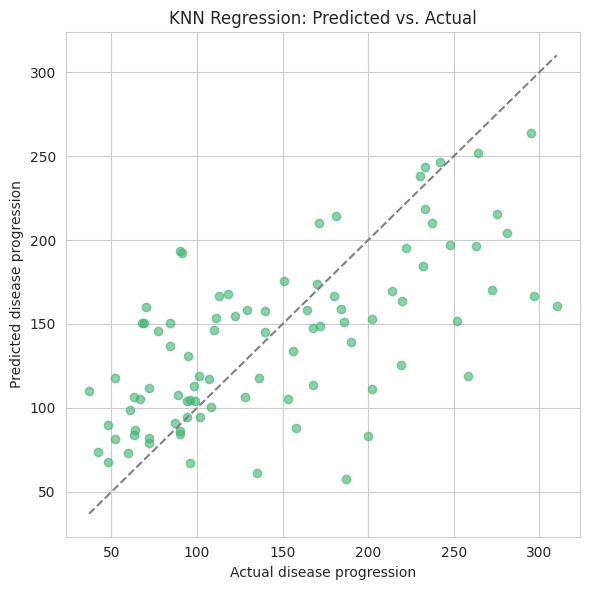

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(yd_test, yd_pred, alpha=0.6, color="mediumseagreen")
lims = [min(yd_test.min(), yd_pred.min()), max(yd_test.max(), yd_pred.max())]
plt.plot(lims, lims, linestyle="--", color="gray")
plt.xlabel("Actual disease progression")
plt.ylabel("Predicted disease progression")
plt.title("KNN Regression: Predicted vs. Actual")
plt.tight_layout()
plt.show()


Just like in classification, K needs to be tuned for regression too — here we look at
**Mean Squared Error** instead of accuracy (lower is better).


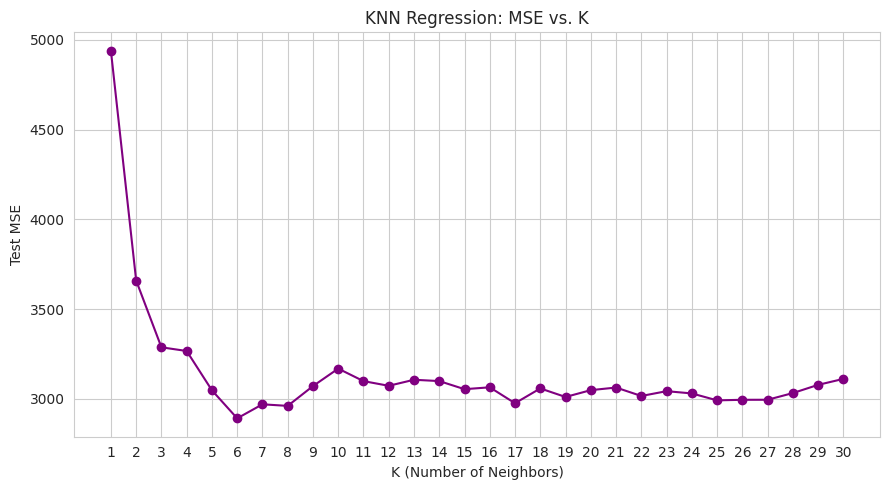

Best K for regression: 6 (MSE = 2891.34)


In [ ]:
k_range_reg = range(1, 31)
mse_scores = []

for k in k_range_reg:
    model = KNeighborsRegressor(n_neighbors=k, metric="euclidean")
    model.fit(Xd_train_scaled, yd_train)
    pred = model.predict(Xd_test_scaled)
    mse_scores.append(mean_squared_error(yd_test, pred))

plt.figure(figsize=(9, 5))
plt.plot(list(k_range_reg), mse_scores, marker="o", color="purple")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test MSE")
plt.title("KNN Regression: MSE vs. K")
plt.xticks(list(k_range_reg))
plt.tight_layout()
plt.show()

best_k_reg = list(k_range_reg)[np.argmin(mse_scores)]
print(f"Best K for regression: {best_k_reg} (MSE = {min(mse_scores):.2f})")


## 9. Advantages and Limitations of KNN

### ✅ Advantages
- **Simple and intuitive** — easy to explain to non-technical stakeholders ("it looks at
  similar past cases").
- **No training phase / no assumptions about data distribution** — it's a *non-parametric*
  method, so it doesn't assume the data follows a particular shape (unlike, say, Linear
  Regression assuming linearity).
- **Naturally handles multi-class problems** without any modification.
- **Works for both classification and regression** with the same underlying idea.
- **Adapts easily** — adding new training data doesn't require retraining a model; it's
  simply added to the stored dataset.

### ⚠️ Limitations
- **Slow at prediction time** — unlike eager learners, all the computation happens when you
  ask for a prediction, which can be costly with large datasets (more in the next section).
- **Sensitive to feature scale** — as we saw, features must be scaled or a large-range feature
  will dominate the distance calculation.
- **Sensitive to irrelevant features and the curse of dimensionality** — with many
  features, "distance" starts to lose meaning (points all seem equally far apart), which can
  hurt accuracy. Feature selection / dimensionality reduction often helps.
- **Sensitive to imbalanced data** — if one class vastly outnumbers another, votes are more
  likely to be dominated by the majority class regardless of true proximity.
- **Memory-heavy** — the entire training dataset must be stored and available at prediction
  time (no compact learned model).
- **Choosing K and the distance metric requires tuning** — there's no single "correct" value.


## 10. Computational Complexity

Let $n$ = number of training samples, $d$ = number of features (dimensions), and $k$ = number
of neighbors.

### Training
- KNN has effectively **no training cost**: $O(1)$ (or at most $O(n)$ if using a tree
  structure that must be built once, like a KD-Tree or Ball Tree). This is the flip side of
  being a lazy learner.

### Prediction (per query point)
- **Brute-force search:** compute distance to every training point, then sort:
  $O(n \cdot d)$ for distances + $O(n \log n)$ for sorting (or $O(n \cdot k)$ with a
  partial selection algorithm). This becomes expensive as $n$ grows.
- **KD-Tree:** roughly $O(d \log n)$ average case in low dimensions — much faster, but its
  advantage shrinks as $d$ grows large (this is part of the *curse of dimensionality*).
- **Ball Tree:** similar benefits to KD-Tree, but tends to hold up better in higher
  dimensions than KD-Tree.

### Space complexity
- $O(n \cdot d)$ — the entire training set must be stored in memory.

scikit-learn's `KNeighborsClassifier`/`Regressor` automatically picks a good algorithm
(`algorithm='auto'`), but we can also compare them directly.


In [ ]:
# Empirically compare brute-force vs. KD-Tree prediction time
algorithms = ["brute", "kd_tree", "ball_tree"]
timings = {}

for algo in algorithms:
    model = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    model.fit(X_train_scaled, y_train)

    start = time.time()
    for _ in range(20):  # repeat predictions for a more stable timing measurement
        model.predict(X_test_scaled)
    elapsed = (time.time() - start) / 20
    timings[algo] = elapsed

for algo, t in timings.items():
    print(f"{algo:10s} -> avg prediction time: {t*1000:.3f} ms")


brute      -> avg prediction time: 1.260 ms
kd_tree    -> avg prediction time: 2.122 ms
ball_tree  -> avg prediction time: 1.800 ms


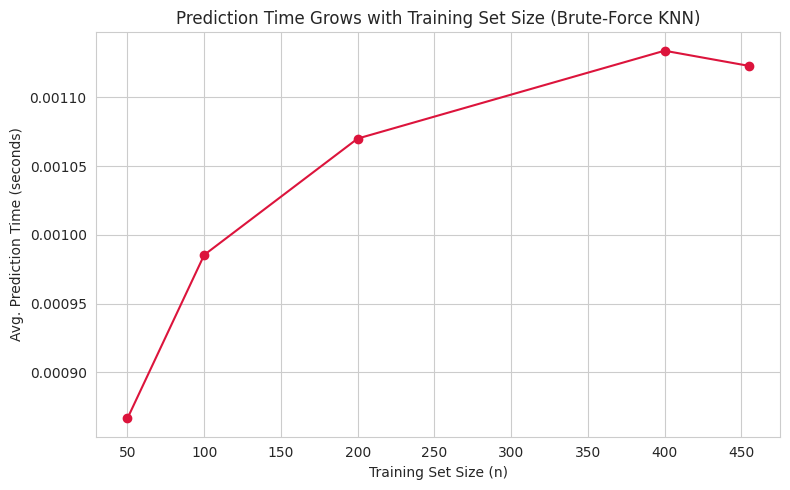

In [ ]:
# How prediction time scales with training set size (brute-force)
sizes = [50, 100, 200, 400, len(X_train_scaled)]
scaling_times = []

for size in sizes:
    model = KNeighborsClassifier(n_neighbors=5, algorithm="brute")
    model.fit(X_train_scaled[:size], y_train.values[:size])
    start = time.time()
    for _ in range(20):
        model.predict(X_test_scaled)
    scaling_times.append((time.time() - start) / 20)

plt.figure(figsize=(8, 5))
plt.plot(sizes, scaling_times, marker="o", color="crimson")
plt.xlabel("Training Set Size (n)")
plt.ylabel("Avg. Prediction Time (seconds)")
plt.title("Prediction Time Grows with Training Set Size (Brute-Force KNN)")
plt.tight_layout()
plt.show()


### Bonus: The Curse of Dimensionality

As the number of features grows, distances between points become less meaningful — nearly
every point ends up roughly equidistant from every other point, which weakens KNN's core
assumption ("close points are similar"). Let's demonstrate this with random synthetic data.


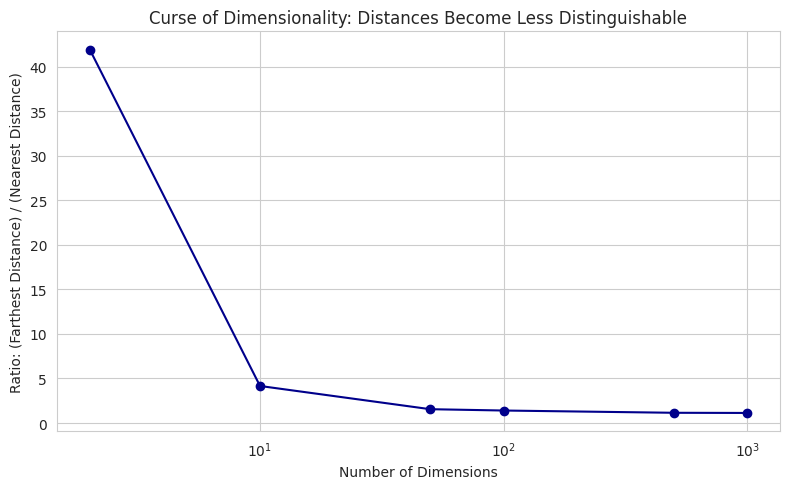

Dimensions:     2 -> max/min distance ratio: 41.929
Dimensions:    10 -> max/min distance ratio: 4.157
Dimensions:    50 -> max/min distance ratio: 1.551
Dimensions:   100 -> max/min distance ratio: 1.402
Dimensions:   500 -> max/min distance ratio: 1.148
Dimensions:  1000 -> max/min distance ratio: 1.130


In [ ]:
dimensions = [2, 10, 50, 100, 500, 1000]
ratios = []

n_points = 500
for d in dimensions:
    pts = np.random.rand(n_points, d)
    query = np.random.rand(1, d)
    dists = np.sqrt(np.sum((pts - query) ** 2, axis=1))
    ratios.append(dists.max() / dists.min())

plt.figure(figsize=(8, 5))
plt.plot(dimensions, ratios, marker="o", color="darkblue")
plt.xlabel("Number of Dimensions")
plt.ylabel("Ratio: (Farthest Distance) / (Nearest Distance)")
plt.title("Curse of Dimensionality: Distances Become Less Distinguishable")
plt.xscale("log")
plt.tight_layout()
plt.show()

for d, r in zip(dimensions, ratios):
    print(f"Dimensions: {d:5d} -> max/min distance ratio: {r:.3f}")


As dimensions increase, that ratio approaches **1.0** — meaning the farthest point and
the nearest point are almost the same distance away! This is precisely why KNN (and other
distance-based methods) can struggle in very high-dimensional spaces, and why techniques like
feature selection, PCA, or using Manhattan distance are common companions to KNN on
high-dimensional data.


## 11. Summary

| Topic | Key Takeaway |
|---|---|
| **What KNN does** | Predicts by finding the K closest training points and voting (classification) or averaging (regression) |
| **Distance metrics** | Euclidean = straight-line distance (good default); Manhattan = grid-like distance (robust to outliers, good in high dimensions) |
| **Feature scaling** | Mandatory — unscaled features with large ranges will dominate the distance calculation |
| **Choosing K** | Small K → overfitting / noisy boundaries; Large K → underfitting / oversmoothed boundaries; use cross-validation or an elbow plot to choose |
| **KNN Classification vs. Regression** | Same neighbor-finding mechanism; classification votes on labels, regression averages numeric targets |
| **Advantages** | Simple, no training phase, no distributional assumptions, naturally multi-class |
| **Limitations** | Slow predictions on large data, sensitive to scale/dimensionality/imbalance, memory-heavy |
| **Complexity** | ~$O(1)$ training, $O(n \cdot d)$ brute-force prediction (improved by KD-Tree/Ball Tree in lower dimensions); $O(n \cdot d)$ memory |

### When should you reach for KNN in practice?
- Small-to-medium sized datasets with meaningful, well-scaled numeric features.
- Problems where "similar inputs should have similar outputs" is a reasonable assumption.
- Situations where a simple, interpretable baseline is valuable before trying more complex
  models.
- **Less ideal** for very large datasets (slow predictions) or very high-dimensional data
  without dimensionality reduction.

This notebook used clean, built-in datasets (Breast Cancer Wisconsin & Diabetes) specifically
so the concepts — distance, scaling, K selection, complexity — stayed front and center rather
than getting lost in data cleaning. The same workflow applies directly to messier real-world
data once these fundamentals are solid.
